# EDA — RetailRocket `events.csv`

Notebook exploratório e descartável (sandbox `new_repo/`). Objetivo: entender o dado de interações antes de decidir qualquer coisa sobre pré-processamento, corte de cold-start, negative sampling ou features — para o novo repositório, escrito do zero.

Perguntas que este notebook responde:
1. Como é o funil de eventos (view → addtocart → transaction)?
2. Quão esparsa é a matriz usuário-item?
3. Existe cauda longa de popularidade de itens?
4. Que limite de cold-start (`min_interactions`) faz sentido?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../../data/raw/events.csv"

events = pd.read_csv(DATA_PATH)
# timestamp vem em epoch ms, converte pra datetime só pra facilitar leitura nos prints
events["datetime"] = pd.to_datetime(events["timestamp"], unit="ms")
events.shape

(2756101, 6)

In [2]:
events.head()

,timestamp,visitorid,event,itemid,transactionid,datetime
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106


In [3]:
print("Período:", events["datetime"].min(), "->", events["datetime"].max())
print("Visitantes únicos:", events["visitorid"].nunique())
print("Itens únicos:", events["itemid"].nunique())
print("Eventos totais:", len(events))
events["event"].value_counts()

Periodo: 2015-05-03 03:00:04.384000 -> 2015-09-18 02:59:47.788000
Visitantes unicos: 1407580
Itens unicos: 235061
Eventos totais: 2756101


event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

## 1. Funil de conversão

`view -> addtocart -> transaction`. Cada evento é uma linha; não há like/dislike explícito, só feedback implícito.

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

view -> addtocart: 2.60%
addtocart -> transaction: 32.39%
view -> transaction: 0.84%


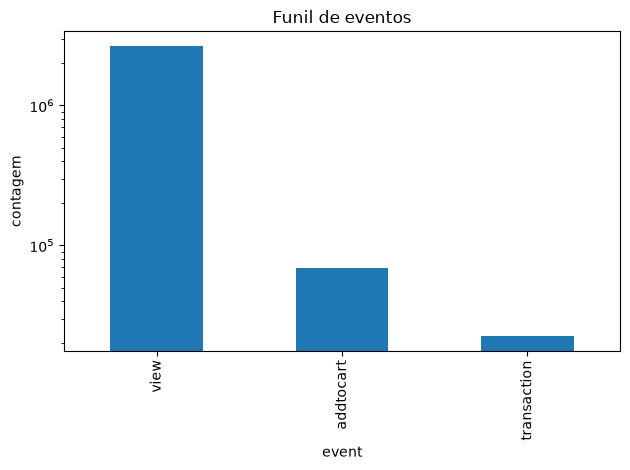

In [4]:
funnel = events["event"].value_counts().reindex(["view", "addtocart", "transaction"])
conv_view_to_cart = funnel["addtocart"] / funnel["view"]
conv_cart_to_txn = funnel["transaction"] / funnel["addtocart"]
conv_view_to_txn = funnel["transaction"] / funnel["view"]

print(funnel)
print(f"\nview -> addtocart: {conv_view_to_cart:.2%}")
print(f"addtocart -> transaction: {conv_cart_to_txn:.2%}")
print(f"view -> transaction: {conv_view_to_txn:.2%}")

funnel.plot(kind="bar", title="Funil de eventos", ylabel="contagem")
plt.yscale("log")
plt.tight_layout()
plt.show()

## 2. Esparsidade usuário-item

Distribuição de quantas interações cada usuário e cada item tem. Isso é o que vai justificar (ou não) negative sampling e o limite de cold-start.

In [5]:
interactions_per_user = events.groupby("visitorid").size()
interactions_per_item = events.groupby("itemid").size()

print("Interações por usuário:")
print(interactions_per_user.describe(percentiles=[.5, .75, .9, .95, .99]))
print("\nInteracoes por item:")
print(interactions_per_item.describe(percentiles=[.5, .75, .9, .95, .99]))

Interacoes por usuario:
count    1.407580e+06
mean     1.958042e+00
std      1.258049e+01
min      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
90%      3.000000e+00
95%      5.000000e+00
99%      1.300000e+01
max      7.757000e+03
dtype: float64

Interacoes por item:
count    235061.000000
mean         11.725046
std          37.032101
min           1.000000
50%           3.000000
75%           9.000000
90%          25.000000
95%          47.000000
99%         143.000000
max        3412.000000
dtype: float64


In [6]:
n_users = events["visitorid"].nunique()
n_items = events["itemid"].nunique()
n_possible_pairs = n_users * n_items
n_observed_pairs = events.drop_duplicates(["visitorid", "itemid"]).shape[0]

sparsity = 1 - (n_observed_pairs / n_possible_pairs)
print(f"Pares (usuário, item) observados: {n_observed_pairs:,}")
print(f"Pares possíveis (n_users x n_items): {n_possible_pairs:,}")
print(f"Esparsidade: {sparsity:.6%} da matriz está vazia")

Pares (usuario, item) observados: 2,145,179
Pares possiveis (n_users x n_items): 330,867,162,380
Esparsidade: 99.999352% da matriz esta vazia


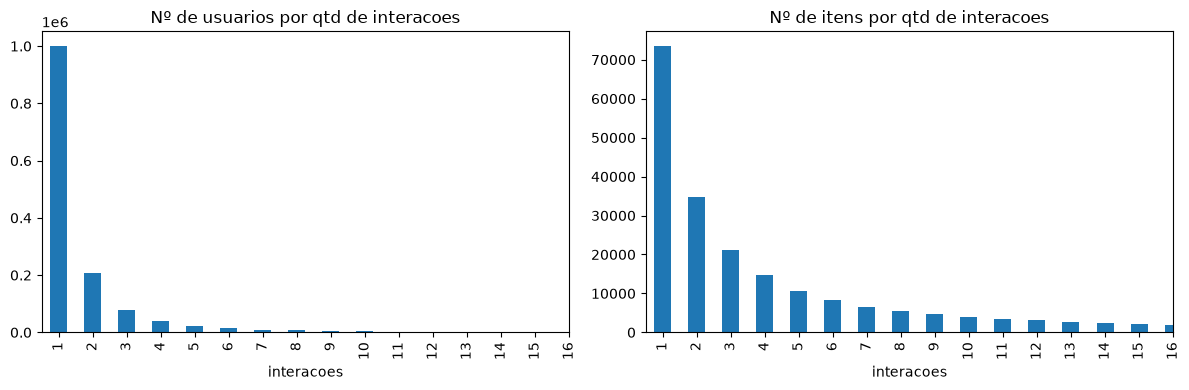

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
interactions_per_user.value_counts().sort_index().plot(
    kind="bar", ax=axes[0], title="Nº de usuários por qtd de interações"
)
axes[0].set_xlim(-0.5, 15)
axes[0].set_xlabel("interações")

interactions_per_item.value_counts().sort_index().plot(
    kind="bar", ax=axes[1], title="Nº de itens por qtd de interações"
)
axes[1].set_xlim(-0.5, 15)
axes[1].set_xlabel("interações")
plt.tight_layout()
plt.show()

## 3. Cauda longa de popularidade de itens

Quanto da interação total está concentrada em poucos itens?

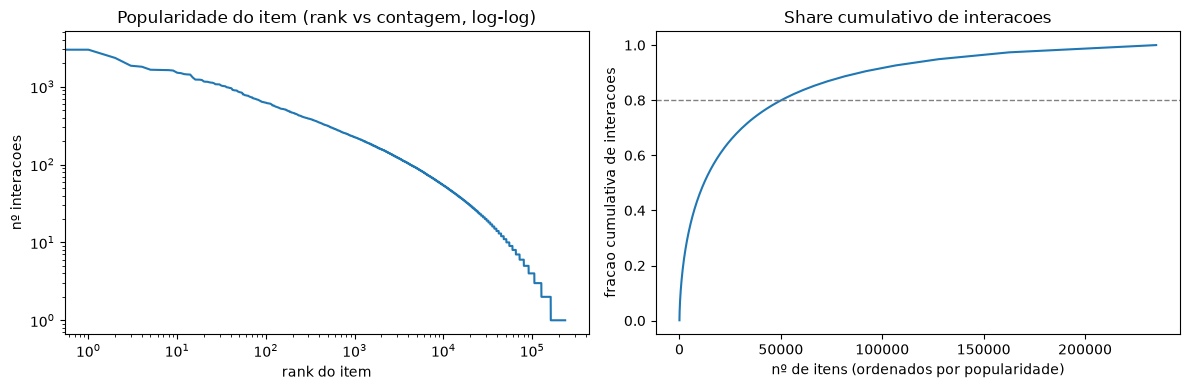

Top 1% dos itens (2350 itens) concentram 23.0% das interacoes


In [8]:
item_popularity = interactions_per_item.sort_values(ascending=False).reset_index(drop=True)
cumulative_share = item_popularity.cumsum() / item_popularity.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(item_popularity.values)
axes[0].set_yscale("log")
axes[0].set_xscale("log")
axes[0].set_title("Popularidade do item (rank vs contagem, log-log)")
axes[0].set_xlabel("rank do item")
axes[0].set_ylabel("nº interações")

axes[1].plot(cumulative_share.values)
axes[1].set_title("Share cumulativo de interações")
axes[1].set_xlabel("nº de itens (ordenados por popularidade)")
axes[1].set_ylabel("fração cumulativa de interações")
axes[1].axhline(0.8, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

top_1pct = int(0.01 * len(item_popularity))
print(f"Top 1% dos itens ({top_1pct} itens) concentram {cumulative_share[top_1pct]:.1%} das interações")

## 4. Escolhendo o limite de cold-start

Quantos usuários/itens sobrevivem (e quanta interação se perde) para alguns valores candidatos de `min_interactions`?

In [9]:
candidates = [1, 2, 3, 5, 10]
rows = []
for min_int in candidates:
    kept_users = interactions_per_user[interactions_per_user >= min_int].index
    kept_items = interactions_per_item[interactions_per_item >= min_int].index
    mask = events["visitorid"].isin(kept_users) & events["itemid"].isin(kept_items)
    rows.append({
        "min_interactions": min_int,
        "usuarios_restantes": len(kept_users),
        "pct_usuarios": len(kept_users) / n_users,
        "itens_restantes": len(kept_items),
        "pct_itens": len(kept_items) / n_items,
        "pct_eventos_mantidos": mask.mean(),
    })

pd.DataFrame(rows).style.format({
    "pct_usuarios": "{:.1%}".format,
    "pct_itens": "{:.1%}".format,
    "pct_eventos_mantidos": "{:.1%}".format,
})

,min_interactions,usuarios_restantes,pct_usuarios,itens_restantes,pct_itens,pct_eventos_mantidos
0,1,1407580,100.0%,235061,100.0%,100.0%
1,2,406020,28.8%,161452,68.7%,62.6%
2,3,200028,14.2%,126623,53.9%,47.3%
3,5,81620,5.8%,90948,38.7%,32.5%
4,10,23241,1.7%,55128,23.5%,18.7%


## Conclusões

- **Funil:** só 0,84% dos `view` viram `transaction` (2,66M views -> 22,4k transações).
  Usar só `transaction` como rotulo positivo esfomearia o modelo de exemplos —
  confirma que a abordagem certa é **feedback implícito** (qualquer evento conta
  como sinal positivo), o que por sua vez exige negative sampling (não ha
  negativo natural: ausência de interação != rejeição).
- **Esparsidade:** usuário mediano tem **1 interação na vida toda**; matriz
  99,9994% vazia. É o motivo estrutural (não só uma hipótese) de por que
  embeddings (rede neural) tendem a aprender mal aqui — uma linha de embedding
  tocada por 1 único exemplo não generaliza — enquanto features de contagem
  (popularidade do item) carregam sinal mesmo para um usuário quase cold-start,
  porque são calculadas sobre a base inteira, não por usuário.
- **Cauda longa:** top 1% dos itens concentra 23% das interações — moderado,
  não extremo. Justifica popularidade do item como feature forte, e sugere
  adicionar um baseline "mais popular" (zero treino) como sanity check: se um
  modelo de verdade não bate isso, algo está errado.
- **`min_interactions` escolhido: 3.** É o mínimo que permite um split
  leave-one-out de 3 vias (train/val/test) sem casos degenerados. Mantém
  14,2% dos usuários e 53,9% dos itens — mais agressivo (min=5 ou 10) preserva
  menos itens sem ganho proporcional em eventos mantidos (a curva não é linear:
  de min=2 para min=5, usuários caem ~5x mas eventos caem só ~2x).
- **Limitação a documentar no Model Card:** com `min_interactions=3`, o sistema
  só personaliza para ~14% dos usuários — o resto (visitantes de 1-2 eventos)
  precisaria de um fallback (ex.: o baseline de popularidade) em produção real.
  Isso é uma limitação real do dado, não um erro de modelagem.
- **Features tabulares candidatas para os modelos de árvore:** contagem de
  atividade do usuário, contagem de popularidade do item, recência — todas
  calculadas sobre a base inteira (não só o histórico do usuário), pelo motivo
  do ponto de esparsidade acima.

## 5. Negative sampling — o que é e como funciona

O dado só tem **positivos implícitos** (o usuário interagiu com o item — não sabemos se ele *rejeitou* algo). Pra treinar um classificador ou calcular métricas de ranking, precisamos de exemplos negativos: pares (usuário, item) que representam "o usuário não interagiu com este item".

**Negative sampling** = para cada interação positiva de um usuário, sortear N itens que esse usuário **nunca** interagiu (em nenhum split — train, val ou test), e rotulá-los como negativo (`label=0`). O positivo real vira `label=1`.

Dois cuidados que fazem isso funcionar corretamente:
1. **Excluir de TODOS os splits, não só do positivo atual.** Se um negativo sorteado para o treino for na verdade um item que o usuário só vai interagir no `test`, isso vaza informação (o modelo veria como negativo algo que é positivo mais adiante).
2. **Proporção diferente treino vs avaliação.** Convenção padrão (leave-one-out em sistemas de recomendação): **1:4** (1 positivo : 4 negativos) no treino — desbalanceado o bastante pra não afogar o sinal positivo, mas com negativos suficientes pra o modelo aprender a discriminar — e **1:99** na avaliação, simulando o cenário real de "ranquear 1 item relevante entre ~100 candidatos", que é exatamente contra o que NDCG@k/Hit Rate@k são calculados.

In [10]:
MIN_INTERACTIONS = 3

def filter_cold_start(df, min_interactions):
    """Remove usuários/itens abaixo do limite, repetindo até convergir
    (remover um usuário pode derrubar um item abaixo do limite, e vice-versa)."""
    while True:
        user_counts = df.groupby("visitorid").size()
        item_counts = df.groupby("itemid").size()
        valid_users = user_counts[user_counts >= min_interactions].index
        valid_items = item_counts[item_counts >= min_interactions].index
        new_df = df[df["visitorid"].isin(valid_users) & df["itemid"].isin(valid_items)]
        if len(new_df) == len(df):
            return new_df
        df = new_df

filtered = filter_cold_start(events, MIN_INTERACTIONS)
print(f"Eventos: {len(events):,} -> {len(filtered):,} ({len(filtered) / len(events):.1%})")
print(f"Usuários: {events['visitorid'].nunique():,} -> {filtered['visitorid'].nunique():,}")
print(f"Itens: {events['itemid'].nunique():,} -> {filtered['itemid'].nunique():,}")

Eventos: 2,756,101 -> 1,225,443 (44.5%)
Usuarios: 1,407,580 -> 179,877


Itens: 235,061 -> 68,067


In [11]:
deduped = (
    filtered.sort_values("timestamp")
    .drop_duplicates(["visitorid", "itemid"], keep="last")
)
print(f"Interações (usuário,item) únicas após dedupe: {len(deduped):,}")

def assign_loo_splits(df):
    """Leave-one-out por usuário: última interação -> test, penúltima -> val, resto -> train."""
    df = df.sort_values(["visitorid", "timestamp"]).copy()
    rank_desc = df.groupby("visitorid").cumcount(ascending=False)
    df["split"] = np.select(
        [rank_desc == 0, rank_desc == 1],
        ["test", "val"],
        default="train",
    )
    return df

split_df = assign_loo_splits(deduped)
split_df["split"].value_counts()

Interacoes (usuario,item) unicas apos dedupe: 713,404


split
train    387611
test     179877
val      145916
Name: count, dtype: int64

In [12]:
# Positivos por usuário considerando TODOS os splits (train+val+test) —
# é o que garante que um negativo sorteado nunca seja "positivo em outro split".
positive_items_by_user = deduped.groupby("visitorid")["itemid"].apply(set).to_dict()
all_items = filtered["itemid"].unique()
print(f"Universo de itens candidatos para negative sampling: {len(all_items):,}")

Universo de itens candidatos para negative sampling: 68,067


In [13]:
def sample_negatives(user_ids, positive_items_by_user, all_items, n_neg_per_user, rng):
    """Para cada user_id, sorteia n_neg_per_user itens que ele nunca interagiu.

    Rejection sampling: sorteia um lote de candidatos, descarta os que colidem
    com um positivo (ou que já foram escolhidos), repete só para o que faltar.
    """
    all_items = np.asarray(all_items)
    n_items = len(all_items)
    out_users, out_items = [], []

    for user_id in user_ids:
        positives = positive_items_by_user[user_id]
        chosen = set()
        while len(chosen) < n_neg_per_user:
            missing = n_neg_per_user - len(chosen)
            candidates = all_items[rng.integers(0, n_items, size=missing * 2)]
            for item_id in candidates:
                if item_id not in positives and item_id not in chosen:
                    chosen.add(item_id)
                    if len(chosen) == n_neg_per_user:
                        break
        out_users.extend([user_id] * n_neg_per_user)
        out_items.extend(chosen)

    return pd.DataFrame({"visitorid": out_users, "itemid": out_items, "label": 0})

In [14]:
rng = np.random.default_rng(42)

# Demo em 1 usuário concreto, pra ver o mecanismo na prática
demo_user = split_df["visitorid"].iloc[0]
print(f"Usuário de exemplo: {demo_user}")
print(f"Itens positivos (todos os splits): {sorted(positive_items_by_user[demo_user])}")

demo_negatives = sample_negatives([demo_user], positive_items_by_user, all_items, n_neg_per_user=4, rng=rng)
print(f"\n4 negativos sorteados:\n{demo_negatives}")

overlap = set(demo_negatives['itemid']) & positive_items_by_user[demo_user]
print(f"\nInterseccao negativos x positivos (deve ser vazia): {overlap}")

Usuario de exemplo: 0
Itens positivos (todos os splits): [67045, 285930, 357564]

4 negativos sorteados:
   visitorid  itemid  label
0          0  305843      0
1          0  403622      0
2          0  144822      0
3          0  387164      0

Interseccao negativos x positivos (deve ser vazia): set()


In [15]:
import time

# Teste em escala (amostra de usuários, pra manter o notebook rápido —
# a versao de produção do script vetoriza isso para o dataset inteiro).
SAMPLE_SIZE = 3000
sample_users = rng.choice(split_df["visitorid"].unique(), size=SAMPLE_SIZE, replace=False)

train_positives = split_df[(split_df["split"] == "train") & (split_df["visitorid"].isin(sample_users))]
val_positives = split_df[(split_df["split"] == "val") & (split_df["visitorid"].isin(sample_users))]

t0 = time.time()
train_negatives = sample_negatives(
    train_positives["visitorid"], positive_items_by_user, all_items, n_neg_per_user=4, rng=rng
)
val_negatives = sample_negatives(
    val_positives["visitorid"], positive_items_by_user, all_items, n_neg_per_user=99, rng=rng
)
elapsed = time.time() - t0

print(f"Tempo para {SAMPLE_SIZE} usuários (treino 1:4 + val 1:99): {elapsed:.2f}s")
print(f"\nTrain: {len(train_positives):,} positivos + {len(train_negatives):,} negativos "
      f"-> {len(train_negatives) / len(train_positives):.1f} negativos/positivo")
print(f"Val:   {len(val_positives):,} positivos + {len(val_negatives):,} negativos "
      f"-> {len(val_negatives) / len(val_positives):.1f} negativos/positivo")

# Sanity check: nenhum negativo sorteado pode ser um positivo conhecido do mesmo usuário
merged = train_negatives.merge(
    deduped[["visitorid", "itemid"]].assign(is_positive=True),
    on=["visitorid", "itemid"], how="left"
)
n_leaks = merged["is_positive"].sum()
print(f"\nNegativos que na verdade eram positivos (deveria ser 0): {n_leaks}")
assert n_leaks == 0, "Vazamento: um negativo sorteado coincide com um positivo real"

Tempo para 3000 usuarios (treino 1:4 + val 1:99): 0.30s

Train: 5,661 positivos + 22,644 negativos -> 4.0 negativos/positivo
Val:   2,382 positivos + 235,818 negativos -> 99.0 negativos/positivo



Negativos que na verdade eram positivos (deveria ser 0): 0


## 6. Montando as tabelas completas para um primeiro baseline

Agora para valer: gerar as tabelas de treino/val/test para **todos os 179.877 usuários** (não só a amostra de 3.000 usada para testar o mecanismo), e treinar um primeiro modelo de verdade em cima delas.

In [16]:
train_positives_full = split_df.loc[split_df["split"] == "train", ["visitorid", "itemid"]].assign(label=1)
val_positives_full = split_df.loc[split_df["split"] == "val", ["visitorid", "itemid"]].assign(label=1)
test_positives_full = split_df.loc[split_df["split"] == "test", ["visitorid", "itemid"]].assign(label=1)

print(f"Train positivos: {len(train_positives_full):,}")
print(f"Val positivos:   {len(val_positives_full):,}")
print(f"Test positivos:  {len(test_positives_full):,}")

Train positivos: 387,611
Val positivos:   145,916
Test positivos:  179,877


In [17]:
rng_full = np.random.default_rng(42)

t0 = time.time()
train_negatives_full = sample_negatives(
    train_positives_full["visitorid"], positive_items_by_user, all_items, n_neg_per_user=4, rng=rng_full
)
print(f"train negatives: {len(train_negatives_full):,} linhas em {time.time() - t0:.1f}s")

t0 = time.time()
val_negatives_full = sample_negatives(
    val_positives_full["visitorid"], positive_items_by_user, all_items, n_neg_per_user=99, rng=rng_full
)
print(f"val negatives:   {len(val_negatives_full):,} linhas em {time.time() - t0:.1f}s")

t0 = time.time()
test_negatives_full = sample_negatives(
    test_positives_full["visitorid"], positive_items_by_user, all_items, n_neg_per_user=99, rng=rng_full
)
print(f"test negatives:  {len(test_negatives_full):,} linhas em {time.time() - t0:.1f}s")

train negatives: 1,550,444 linhas em 3.9s


val negatives:   14,445,684 linhas em 15.9s


test negatives:  17,807,823 linhas em 18.7s


In [18]:
def build_labeled_table(positives, negatives, seed):
    table = pd.concat([positives, negatives], ignore_index=True)
    return table.sample(frac=1, random_state=seed).reset_index(drop=True)

train_table = build_labeled_table(train_positives_full, train_negatives_full, seed=1)
val_table = build_labeled_table(val_positives_full, val_negatives_full, seed=2)
test_table = build_labeled_table(test_positives_full, test_negatives_full, seed=3)

print("Train label counts:\n", train_table["label"].value_counts())
print("\nVal label counts:\n", val_table["label"].value_counts())
print("\nTest label counts:\n", test_table["label"].value_counts())

Train label counts:
 label
0    1550444
1     387611
Name: count, dtype: int64

Val label counts:
 label
0    14445684
1      145916
Name: count, dtype: int64

Test label counts:
 label
0    17807823
1      179877
Name: count, dtype: int64


## 7. Feature engineering `fe_v1` — 3 features simples

Calculadas **só a partir do `train`** (nunca de val/test, pra não vazar informação), depois aplicadas por join nos três splits:

- `user_activity_count` — quantos itens **distintos** esse usuário interagiu no treino.
- `item_popularity_count` — quantos usuários **distintos** interagiram com esse item no treino.
- `item_recency_days` — há quantos dias foi a última interação com esse item no treino (relativo ao timestamp mais recente do dataset).

Como essas contagens vem do `split_df` (que já é deduplicado), elas contam **itens/usuários distintos**, não eventos brutos — a mesma distinção que apareceu na discussão sobre `min_interactions`.

In [19]:
REFERENCE_TIMESTAMP = filtered["timestamp"].max()

train_events_with_time = split_df.loc[split_df["split"] == "train", ["visitorid", "itemid", "timestamp"]]

user_activity = train_events_with_time.groupby("visitorid").size().rename("user_activity_count")
item_popularity = train_events_with_time.groupby("itemid").size().rename("item_popularity_count")
item_last_seen = train_events_with_time.groupby("itemid")["timestamp"].max()
# timestamp original é em ms, por isso a conta feia de dividir por 1000*60*60*24 pra virar dias
item_recency_days = ((REFERENCE_TIMESTAMP - item_last_seen) / (1000 * 60 * 60 * 24)).rename("item_recency_days")

print("user_activity_count:\n", user_activity.describe())
print("\nitem_popularity_count:\n", item_popularity.describe())
print("\nitem_recency_days:\n", item_recency_days.describe())

user_activity_count:


 count    99890.000000
mean         3.880378
std         24.270925
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max       3644.000000
Name: user_activity_count, dtype: float64

item_popularity_count:
 count    56526.000000
mean         6.857216
std         11.285740
min          1.000000
25%          2.000000
50%          3.000000
75%          7.000000
max        349.000000
Name: item_popularity_count, dtype: float64

item_recency_days:
 count    56526.000000
mean        46.530999
std         36.852024
min          0.001907
25%         14.039951
50%         39.458245
75%         71.430100
max        137.949590
Name: item_recency_days, dtype: float64


In [20]:
FEATURE_COLUMNS = ["user_activity_count", "item_popularity_count", "item_recency_days"]
MAX_RECENCY_DAYS = item_recency_days.max()

def add_features(table):
    table = table.merge(user_activity, left_on="visitorid", right_index=True, how="left")
    table = table.merge(item_popularity, left_on="itemid", right_index=True, how="left")
    table = table.merge(item_recency_days, left_on="itemid", right_index=True, how="left")
    # usuário/item sem histórico no TREINO (mesmo sobrevivendo ao filtro geral de min_interactions,
    # que conta eventos em todos os splits) -> tratado como o caso mais "frio" possível
    table["user_activity_count"] = table["user_activity_count"].fillna(0)
    table["item_popularity_count"] = table["item_popularity_count"].fillna(0)
    table["item_recency_days"] = table["item_recency_days"].fillna(MAX_RECENCY_DAYS)
    return table

train_feat = add_features(train_table)
val_feat = add_features(val_table)
test_feat = add_features(test_table)

n_cold_val_users = val_feat.loc[val_feat["user_activity_count"] == 0, "visitorid"].nunique()
n_cold_test_users = test_feat.loc[test_feat["user_activity_count"] == 0, "visitorid"].nunique()
print(f"Usuários em val sem NENHUM histórico de treino: {n_cold_val_users:,}")
print(f"Usuários em test sem NENHUM histórico de treino: {n_cold_test_users:,}")

train_feat[FEATURE_COLUMNS].describe()

Usuarios em val sem NENHUM historico de treino: 46,026
Usuarios em test sem NENHUM historico de treino: 79,987


,user_activity_count,item_popularity_count,item_recency_days
count,1.938055e+06,1.938055e+06,1.938055e+06
mean,1.556882e+02,9.601042e+00,5.522289e+01
std,4.646480e+02,2.021390e+01,4.697521e+01
min,1.000000e+00,0.000000e+00,1.907106e-03
25%,3.000000e+00,1.000000e+00,1.326743e+01
50%,7.000000e+00,3.000000e+00,4.335070e+01
75%,3.100000e+01,9.000000e+00,9.014005e+01
max,3.644000e+03,3.490000e+02,1.379496e+02


## 8. Métricas de ranking

Cada usuário no eval tem 1 positivo + 99 negativos (100 candidatos). O modelo pontua os 100, ranqueamos por pontuação, e medimos se/onde o positivo aparece no top-k.

Usamos 4 métricas que carregam informação **de verdade** distinta (Precision@10 e Recall@10 foram descartadas por serem, neste protocolo com exatamente 1 item relevante por usuário, apenas reescalas de Hit Rate@10 — nenhuma informação nova):

- **Hit Rate@10** — o item certo apareceu em algum lugar do top-10? (0 ou 1 por usuário)
- **NDCG@10** — além de aparecer, apareceu **perto do topo**? (rank 1 vale mais que rank 10)
- **MRR@10** — fórmula diferente do NDCG (`1/rank` em vez de `1/log2(rank+1)`), também sensível a posição, mas com uma curva mais agressiva perto do topo.
- **Coverage@10** — dos ~68 mil itens do catálogo, quantos **distintos** aparecem em algum top-10 de algum usuário? Essa é a única das 4 que não depende só do "rank do item certo" — mede se o sistema recomenda um pedaço amplo do catálogo ou fica repetindo os mesmos itens populares pra todo mundo. Dado que a árvore usa 99% de importância em `item_popularity_count`, é a métrica que vai confirmar (ou não) a suspeita de que isso hoje é quase um "recomendador de mais populares".

In [21]:
def evaluate_model(model, eval_df, feature_columns, all_items, k=10):
    # Todo usuário tem exatamente 1 positivo + N negativos (grupo de tamanho fixo),
    # então da pra reshapar em uma matriz (n_usuarios x tamanho_do_grupo) e vetorizar
    # tudo com numpy, sem nenhum loop Python por usuário -- ~3x mais rápido que
    # argsort por grupo, e ~15x mais rápido que sort_values por grupo.
    eval_df = eval_df.sort_values("visitorid")
    scores = model.predict_proba(eval_df[feature_columns])[:, 1]
    n_users = eval_df["visitorid"].nunique()
    assert len(eval_df) % n_users == 0, "grupo com tamanho irregular por usuário"
    group_size = len(eval_df) // n_users

    scores_matrix = scores.reshape(n_users, group_size)
    labels_matrix = eval_df["label"].to_numpy().reshape(n_users, group_size)
    items_matrix = eval_df["itemid"].to_numpy().reshape(n_users, group_size)

    order = np.argsort(-scores_matrix, axis=1)
    ranked_labels = np.take_along_axis(labels_matrix, order, axis=1)[:, :k]
    ranked_items = np.take_along_axis(items_matrix, order, axis=1)[:, :k]

    has_hit = ranked_labels.any(axis=1)
    discounts = 1.0 / np.log2(np.arange(2, k + 2))  # IDCG = 1.0 (só 1 item relevante por usuário)
    ndcg = (ranked_labels * discounts).sum(axis=1)
    first_hit_pos = np.argmax(ranked_labels, axis=1)
    mrr = np.where(has_hit, 1.0 / (first_hit_pos + 1), 0.0)
    coverage = len(np.unique(ranked_items)) / len(all_items)

    return {
        "ndcg": ndcg.mean(),
        "hit_rate": has_hit.mean(),
        "mrr": mrr.mean(),
        "coverage": coverage,
    }

## 9. MLflow — configuração e como vamos organizar as runs

Convenção revisada (a primeira tentativa criava uma run "comparison" solta sem métricas, só pra pendurar um grafico — isso é exatamente o tipo de poluição que queremos evitar):

- **1 experimento só** para o projeto inteiro (`ecommerce-recsys`), nunca espalhar em vários.
- **Runs aninhadas (`nested=True`)**: uma **run pai por versao de feature engineering** (`batch-fe_v1`, depois `batch-fe_v2`, ...) e cada modelo testado nessa versao vira uma **run filha** dela (`baseline-logreg`, `tree-decision_tree`, `tree-xgboost`, `tree-lightgbm`). A UI do MLflow mostra isso agrupado/recolhivel — abre a run pai e ve todos os modelos daquele fe de uma vez, sem runs soltas competindo visualmente com as de verdade.
- **O grafico comparativo vira artefato da própria run PAI**, não uma run separada só pra existir — ela literalmente representa "o lote de testes do fe_v1", então um grafico comparando os modelos desse lote pertence a ela por definição.
- **Tags consistentes** em toda run filha: `model_family` (`baseline`/`tree`/`neural`), `feature_set`.
- **As mesmas 4 métricas em toda run filha** (`ndcg`, `hit_rate`, `mrr`, `coverage`), prefixadas `val_`/`test_`.
- **Sem Model Registry ainda** — só os finalistas, no final.

In [ ]:
from pathlib import Path
import mlflow

MLFLOW_DIR = Path("mlflow-data").resolve()
MLFLOW_DIR.mkdir(parents=True, exist_ok=True)

tracking_db = MLFLOW_DIR / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{tracking_db.as_posix()}")

EXPERIMENT_NAME = "ecommerce-recsys"
if mlflow.get_experiment_by_name(EXPERIMENT_NAME) is None:
    artifact_location = (MLFLOW_DIR / "artifacts").resolve().as_uri()
    mlflow.create_experiment(EXPERIMENT_NAME, artifact_location=artifact_location)
mlflow.set_experiment(EXPERIMENT_NAME)

print("Tracking URI:", mlflow.get_tracking_uri())

In [23]:
CATEGORY_NAME = "tree_baseline_models"
category_run_id_path = MLFLOW_DIR / "category_run_id.txt"

if category_run_id_path.exists():
    existing_run_id = category_run_id_path.read_text().strip()
    category_run = mlflow.start_run(run_id=existing_run_id)
    print(f"Retomando categoria existente: tree-baseline-models ({category_run.info.run_id})")
else:
    category_run = mlflow.start_run(run_name="tree-baseline-models")
    mlflow.set_tags({"category": CATEGORY_NAME})
    category_run_id_path.write_text(category_run.info.run_id)
    print(f"Categoria criada: tree-baseline-models ({category_run.info.run_id})")

CATEGORY_RUN_ID = category_run.info.run_id

def batch_exists(feature_set_name):
    """Evita duplicar um batch se o notebook rodar de novo sem apagar o mlflow-data.
    Checagem por nome, não por hash de dependência (isso é o que o DVC vai fazer
    de verdade no repo real) -- se o CÓDIGO de um batch já logado mudar, é preciso
    apagar aquele batch específico (não o mlflow-data inteiro) para forcar o relog."""
    exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    if exp is None:
        return False
    existing = mlflow.search_runs(
        experiment_ids=[exp.experiment_id],
        filter_string=f"tags.feature_set = '{feature_set_name}' and tags.mlflow.runName = 'batch-{feature_set_name}'",
    )
    return len(existing) > 0

Retomando categoria existente: tree-baseline-models (313405af016a4bcba2164a7d5ee731a5)


In [24]:
fe_group_run_id_path = MLFLOW_DIR / "fe_group_run_id.txt"

if fe_group_run_id_path.exists():
    FE_GROUP_ID = fe_group_run_id_path.read_text().strip()
    mlflow.start_run(run_id=FE_GROUP_ID, nested=True)
    print(f"Retomando grupo feature-engineering ({FE_GROUP_ID})")
else:
    fe_group_run = mlflow.start_run(run_name="feature-engineering", nested=True)
    FE_GROUP_ID = fe_group_run.info.run_id
    mlflow.set_tags({"category": CATEGORY_NAME})
    fe_group_run_id_path.write_text(FE_GROUP_ID)
    print(f"Grupo feature-engineering criado ({FE_GROUP_ID})")

Retomando grupo feature-engineering (e5b0e461636c4240b8438120959205ba)


## 10. Treinando e logando os modelos de `fe_v1`

Ordem combinada: baseline (Logistic Regression, exigido pelo desafio) -> árvore simples (Decision Tree) -> árvores com boosting (XGBoost, LightGBM). Os 4 usam as mesmas 3 features e a mesma função `evaluate_model`, então a comparação é limpa — a única coisa que muda entre eles é o estimador.

Antes de treinar: pra poder comparar train/val/test no **mesmo grafico**, o train precisa ser avaliado no mesmo formato 1-positivo-para-99-negativos que val/test usam (o train de treino de verdade usa 1:4, pra não afogar o sinal — mas isso tornaria a métrica @10 trivial: com só 5 candidatos, top-10 sempre contem todos eles). Então geramos uma amostra de negativos **só para avaliação** do train (`train_eval_feat`), nunca usada no `.fit()`.

In [25]:
TRAIN_EVAL_SAMPLE_SIZE = 50_000  # diagnóstico de overfitting, não precisa da população inteira

# Ao contrário de val/test (exatamente 1 item por usuário, por design do leave-one-out),
# train tem MUITOS positivos por usuário (todo o histórico mais antigo). Pra manter o
# mesmo formato "1 positivo + 99 negativos" que evaluate_model espera, amostramos
# exatamente 1 positivo por usuário aqui.
train_eval_users = rng_full.choice(train_positives_full["visitorid"].unique(), size=TRAIN_EVAL_SAMPLE_SIZE, replace=False)
train_eval_positives = (
    train_positives_full[train_positives_full["visitorid"].isin(train_eval_users)]
    .groupby("visitorid", as_index=False)
    .sample(n=1, random_state=5)
)

t0 = time.time()
train_eval_negatives = sample_negatives(
    train_eval_positives["visitorid"], positive_items_by_user, all_items, n_neg_per_user=99, rng=rng_full
)
print(f"train_eval negatives: {len(train_eval_negatives):,} linhas em {time.time() - t0:.1f}s "
      f"(amostra de {TRAIN_EVAL_SAMPLE_SIZE:,} usuários de treino, 1 positivo cada)")

train_eval_table = build_labeled_table(train_eval_positives, train_eval_negatives, seed=4)
train_eval_feat = add_features(train_eval_table)
print(f"train_eval_feat: {len(train_eval_feat):,} linhas ({train_eval_feat['label'].mean():.4%} positivos)")

train_eval negatives: 4,950,000 linhas em 5.3s (amostra de 50,000 usuarios de treino, 1 positivo cada)


train_eval_feat: 5,000,000 linhas (1.0000% positivos)


In [26]:
def plot_metrics_across_splits(train_metrics, val_metrics, test_metrics, title):
    metric_names = list(train_metrics.keys())
    fig, axes = plt.subplots(1, len(metric_names), figsize=(4 * len(metric_names), 3.5))
    for ax, name in zip(axes, metric_names):
        values = [train_metrics[name], val_metrics[name], test_metrics[name]]
        ax.bar(["train", "val", "test"], values, color=["#4C72B0", "#DD8452", "#55A868"])
        ax.set_title(name)
    fig.suptitle(title)
    plt.tight_layout()
    return fig

def plot_feature_importance(model, feature_columns, model_name):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        ylabel = "importância (baseada em impureza/ganho)"
    else:
        # Regressão logistica: |coeficiente| não é diretamente comparável em escala
        # com importância de árvore (features aqui não são padronizadas) -- serve
        # só pra ver a direção/peso relativo DENTRO deste modelo, não entre modelos.
        importances = np.abs(model.coef_[0])
        ylabel = "|coeficiente| (não comparável em escala com árvores)"
    fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.bar(feature_columns, importances)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Importância de features -- {model_name}")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    return fig

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

FEATURE_SET_NAME = "fe_v1"
X_train, y_train = train_feat[FEATURE_COLUMNS], train_feat["label"]

MODEL_SPECS = [
    ("logreg", "baseline", LogisticRegression(max_iter=1000, random_state=42)),
    ("decision_tree", "tree", DecisionTreeClassifier(max_depth=8, random_state=42)),
    ("xgboost", "tree", XGBClassifier(n_estimators=100, max_depth=6, eval_metric="logloss", random_state=42)),
    ("lightgbm", "tree", LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)),
]

def run_and_log(model_name, model_family, estimator):
    """Treina, avalia (train/val/test) e loga como run filha da run pai do batch atual."""
    estimator.fit(X_train, y_train)
    train_metrics = evaluate_model(estimator, train_eval_feat, FEATURE_COLUMNS, all_items, k=10)
    val_metrics = evaluate_model(estimator, val_feat, FEATURE_COLUMNS, all_items, k=10)
    test_metrics = evaluate_model(estimator, test_feat, FEATURE_COLUMNS, all_items, k=10)

    with mlflow.start_run(run_name=f"{model_family}-{model_name}", nested=True):
        mlflow.set_tags({"model_family": model_family, "feature_set": FEATURE_SET_NAME, "category": CATEGORY_NAME})
        mlflow.log_params(estimator.get_params())
        mlflow.log_metrics({f"train_{k}": v for k, v in train_metrics.items()})
        mlflow.log_metrics({f"val_{k}": v for k, v in val_metrics.items()})
        mlflow.log_metrics({f"test_{k}": v for k, v in test_metrics.items()})

        fig_splits = plot_metrics_across_splits(train_metrics, val_metrics, test_metrics, f"{model_family}-{model_name}")
        mlflow.log_figure(fig_splits, "metrics_by_split.png")
        plt.close(fig_splits)

        fig_importance = plot_feature_importance(estimator, FEATURE_COLUMNS, model_name)
        mlflow.log_figure(fig_importance, "feature_importance.png")
        plt.close(fig_importance)

    print(f"Logado: {model_family}-{model_name}")
    row = {"model": model_name, "family": model_family}
    row.update({f"train_{k}": v for k, v in train_metrics.items()})
    row.update({f"val_{k}": v for k, v in val_metrics.items()})
    row.update({f"test_{k}": v for k, v in test_metrics.items()})
    return row

In [28]:
if batch_exists(FEATURE_SET_NAME):
    print(f"batch-{FEATURE_SET_NAME} já logado, pulando.")
else:
    with mlflow.start_run(run_name=f"batch-{FEATURE_SET_NAME}", nested=True) as parent_run:
        mlflow.set_tags({"feature_set": FEATURE_SET_NAME, "category": CATEGORY_NAME})
        batch_rows = [run_and_log(name, family, est) for name, family, est in MODEL_SPECS]
        results_df = pd.DataFrame(batch_rows).set_index("model")

        test_cols = [c for c in results_df.columns if c.startswith("test_")]
        fig, ax = plt.subplots(figsize=(9, 4))
        results_df[test_cols].plot(kind="bar", ax=ax, title=f"Comparação {FEATURE_SET_NAME} (test set)")
        plt.tight_layout()

        mlflow.log_figure(fig, "model_comparison.png")
        results_df.to_csv("model_comparison.csv")
        mlflow.log_artifact("model_comparison.csv")
        Path("model_comparison.csv").unlink()
        plt.show()

    print(f"Run pai: batch-{FEATURE_SET_NAME} ({parent_run.info.run_id})")

batch-fe_v1 ja logado, pulando.


## 11. `fe_v2` — corrigindo o cold-start e uma feature de personalização de verdade

Dois ajustes combinados:

1. **Cold-start em itens únicos, não eventos brutos.** `min_interactions=3` hoje conta linhas de `events.csv` — um usuário que viu o mesmo item 3 vezes sobrevive ao filtro com 0 itens únicos de treino de verdade. A correção: deduplicar **antes** de filtrar, então o filtro só conta itens distintos.
2. **Co-visitação item-item.** Para um candidato, soma quantas vezes ele foi co-visitado (por outros usuários, no treino) com cada item do histórico de treino deste usuário específico — classica collaborative filtering item-a-item, via multiplicação de matriz esparsa. A diagonal (auto-covisitação) é zerada -- sem isso, uma linha de treino positiva "encontra a si mesma" no próprio histórico, inflando o treino bem acima de val/test.

Logamos **duas variantes** da feature de co-visitação, cada uma como seu próprio batch no MLflow:
- **`fe_v2.0`** — soma bruta de co-visitação.
- **`fe_v2.1`** — média por item do histórico (soma / número de itens no histórico), pra remover a dependência do tamanho do histórico do usuário.

As mesmas 3 features de `fe_v1` continuam em ambas, só estamos **adicionando** a 4a.

In [29]:
# Reaplica o pipeline (Fase 3-6 do plano) com o filtro corrigido -- deduplicar
# ANTES de filtrar garante que min_interactions conta itens únicos.
deduped_all_events = events.sort_values("timestamp").drop_duplicates(["visitorid", "itemid"], keep="last")
filtered = filter_cold_start(deduped_all_events, MIN_INTERACTIONS)
split_df = assign_loo_splits(filtered)  # já deduplicado, não precisa dedup de novo

positive_items_by_user = filtered.groupby("visitorid")["itemid"].apply(set).to_dict()
all_items = filtered["itemid"].unique()

n_users_with_train_v1 = 99_890  # da seção 7 (fe_v1): usuários com >=1 item de treino
n_users_with_train_v2 = split_df.loc[split_df["split"] == "train", "visitorid"].nunique()

print(f"Usuários com histórico de treino -- fe_v1 (eventos brutos): {n_users_with_train_v1:,}")
print(f"Usuários com histórico de treino -- fe_v2 (itens únicos):   {n_users_with_train_v2:,}")
print(f"\nfe_v2: {filtered['visitorid'].nunique():,} usuários, {filtered['itemid'].nunique():,} itens sobrevivem")
print(split_df["split"].value_counts())

Usuarios com historico de treino -- fe_v1 (eventos brutos): 99,890
Usuarios com historico de treino -- fe_v2 (itens unicos):   91,630

fe_v2: 91,630 usuarios, 43,849 itens sobrevivem
split
train    360820
val       91630
test      91630
Name: count, dtype: int64


In [30]:
train_positives_full = split_df.loc[split_df["split"] == "train", ["visitorid", "itemid"]].assign(label=1)
val_positives_full = split_df.loc[split_df["split"] == "val", ["visitorid", "itemid"]].assign(label=1)
test_positives_full = split_df.loc[split_df["split"] == "test", ["visitorid", "itemid"]].assign(label=1)

t0 = time.time()
train_negatives_full = sample_negatives(train_positives_full["visitorid"], positive_items_by_user, all_items, n_neg_per_user=4, rng=rng_full)
print(f"train negatives: {len(train_negatives_full):,} linhas em {time.time() - t0:.1f}s")

t0 = time.time()
val_negatives_full = sample_negatives(val_positives_full["visitorid"], positive_items_by_user, all_items, n_neg_per_user=99, rng=rng_full)
print(f"val negatives:   {len(val_negatives_full):,} linhas em {time.time() - t0:.1f}s")

t0 = time.time()
test_negatives_full = sample_negatives(test_positives_full["visitorid"], positive_items_by_user, all_items, n_neg_per_user=99, rng=rng_full)
print(f"test negatives:  {len(test_negatives_full):,} linhas em {time.time() - t0:.1f}s")

train_table = build_labeled_table(train_positives_full, train_negatives_full, seed=10)
val_table = build_labeled_table(val_positives_full, val_negatives_full, seed=11)
test_table = build_labeled_table(test_positives_full, test_negatives_full, seed=12)

print(f"\ntrain: {len(train_table):,} | val: {len(val_table):,} | test: {len(test_table):,}")

train negatives: 1,443,280 linhas em 3.9s


val negatives:   9,071,370 linhas em 12.0s


test negatives:  9,071,370 linhas em 14.8s



train: 1,804,100 | val: 9,163,000 | test: 9,163,000


In [31]:
TRAIN_EVAL_SAMPLE_SIZE = 50_000
train_eval_users = rng_full.choice(train_positives_full["visitorid"].unique(), size=TRAIN_EVAL_SAMPLE_SIZE, replace=False)
train_eval_positives = (
    train_positives_full[train_positives_full["visitorid"].isin(train_eval_users)]
    .groupby("visitorid", as_index=False)
    .sample(n=1, random_state=5)
)

t0 = time.time()
train_eval_negatives = sample_negatives(
    train_eval_positives["visitorid"], positive_items_by_user, all_items, n_neg_per_user=99, rng=rng_full
)
print(f"train_eval negatives: {len(train_eval_negatives):,} linhas em {time.time() - t0:.1f}s")

train_eval_table = build_labeled_table(train_eval_positives, train_eval_negatives, seed=14)
print(f"train_eval_table: {len(train_eval_table):,} linhas")

train_eval negatives: 4,950,000 linhas em 5.6s


train_eval_table: 5,000,000 linhas


In [32]:
# Recalcula as 3 features de fe_v1 sobre o split CORRIGIDO (as globais que
# add_features() usa) -- senao ficariam presas ao split antigo de fe_v1.
REFERENCE_TIMESTAMP = filtered["timestamp"].max()
train_events_with_time = split_df.loc[split_df["split"] == "train", ["visitorid", "itemid", "timestamp"]]

user_activity = train_events_with_time.groupby("visitorid").size().rename("user_activity_count")
item_popularity = train_events_with_time.groupby("itemid").size().rename("item_popularity_count")
item_last_seen = train_events_with_time.groupby("itemid")["timestamp"].max()
item_recency_days = ((REFERENCE_TIMESTAMP - item_last_seen) / (1000 * 60 * 60 * 24)).rename("item_recency_days")
MAX_RECENCY_DAYS = item_recency_days.max()

print(f"Usuários com histórico de treino (fe_v2): {len(user_activity):,}")
print(f"Itens com histórico de treino (fe_v2):    {len(item_popularity):,}")

Usuarios com historico de treino (fe_v2): 91,630
Itens com historico de treino (fe_v2):    43,270


In [33]:
import scipy.sparse as sp

user_ids_train = train_events_with_time["visitorid"].unique()
item_ids_train = train_events_with_time["itemid"].unique()
user_to_idx = {u: i for i, u in enumerate(user_ids_train)}
item_to_idx = {it: i for i, it in enumerate(item_ids_train)}

rows_ = train_events_with_time["visitorid"].map(user_to_idx).to_numpy()
cols_ = train_events_with_time["itemid"].map(item_to_idx).to_numpy()
data_ = np.ones(len(train_events_with_time), dtype=np.float32)
user_item_matrix = sp.csr_matrix((data_, (rows_, cols_)), shape=(len(user_ids_train), len(item_ids_train)))

# item_item_cooc[i, j] = número de usuários (no treino) que interagiram com os itens i E j
item_item_cooc = (user_item_matrix.T @ user_item_matrix).tocsr()

# Zera a diagonal (auto-covisitação) -- sem isso, uma linha de TREINO positiva
# "encontra a si mesma" no próprio histórico do usuário, e cooc[item,item] é só a
# popularidade do item (não um sinal de similaridade de verdade).
item_item_cooc.setdiag(0)
item_item_cooc.eliminate_zeros()

user_train_item_indices = train_events_with_time.groupby("visitorid")["itemid"].apply(
    lambda s: [item_to_idx[i] for i in s]
).to_dict()

print(f"item_item_cooc: {item_item_cooc.shape}, nnz={item_item_cooc.nnz:,} "
      f"({item_item_cooc.data.nbytes / 1e6:.0f}MB de dados)")

# --- fe_v2.2: normalização cosseno -- corrige o viés de popularidade (dois itens
# populares co-ocorrem muito só por acaso; cosine divide cada par por
# sqrt(popularidade_i * popularidade_j), diferente do fe_v2.1 que corrigia pelo
# tamanho do histórico do USUÁRIO, não pela popularidade do ITEM) ---
item_popularity_array = item_popularity.reindex(item_ids_train).fillna(0).to_numpy()
inv_sqrt_pop = 1.0 / np.sqrt(np.maximum(item_popularity_array, 1))
pop_scaler = sp.diags(inv_sqrt_pop)
item_item_cooc_cosine = (pop_scaler @ item_item_cooc @ pop_scaler).tocsr()
print(f"item_item_cooc_cosine: nnz={item_item_cooc_cosine.nnz:,}")

# --- fe_v2.3: co-visitação ponderada por tipo de evento -- addtocart/transaction
# carregam muito mais intenção que um view (funil da EDA: view->addtocart só 2.6%,
# addtocart->transaction 32%), então pesamos a matriz usuário-item por isso em vez
# de tratar todo evento como 1 ---
EVENT_WEIGHTS = {"view": 1, "addtocart": 3, "transaction": 5}
train_pairs = train_events_with_time[["visitorid", "itemid"]].drop_duplicates()
train_raw_events = events.merge(train_pairs, on=["visitorid", "itemid"], how="inner")
train_pair_weights = (
    train_raw_events.assign(weight=train_raw_events["event"].map(EVENT_WEIGHTS))
    .groupby(["visitorid", "itemid"])["weight"].max().reset_index()
)

rows_w = train_pair_weights["visitorid"].map(user_to_idx).to_numpy()
cols_w = train_pair_weights["itemid"].map(item_to_idx).to_numpy()
data_w = train_pair_weights["weight"].to_numpy(dtype=np.float32)
user_item_matrix_weighted = sp.csr_matrix(
    (data_w, (rows_w, cols_w)), shape=(len(user_ids_train), len(item_ids_train))
)
item_item_cooc_weighted = (user_item_matrix_weighted.T @ user_item_matrix_weighted).tocsr()
item_item_cooc_weighted.setdiag(0)
item_item_cooc_weighted.eliminate_zeros()
print(f"item_item_cooc_weighted: nnz={item_item_cooc_weighted.nnz:,}")

item_item_cooc: (43270, 43270), nnz=47,951,704 (192MB de dados)


item_item_cooc_cosine: nnz=47,951,704


item_item_cooc_weighted: nnz=47,951,704


In [34]:
def compute_covisitation_scores_combined(tables_dict, user_train_item_indices, item_to_idx, item_item_cooc, normalize):
    """Uma passada por usuário, reaproveitada entre todas as tabelas -- o custo caro
    (fatiar+somar linhas do item_item_cooc) é por usuário, não por tabela.

    normalize=False -> soma bruta de co-visitação (fe_v2.0)
    normalize=True  -> média por item do histórico, ou seja, soma / len(hist) (fe_v2.1) --
    torna o score comparável entre splits (train tem muitas linhas positivas por usuário,
    val/test só 1, então a soma bruta cresce desproporcionalmente com o histórico do usuário)."""
    combined = pd.concat(
        [df[["visitorid", "itemid"]].assign(__source=name) for name, df in tables_dict.items()],
        ignore_index=True,
    )
    scores = np.zeros(len(combined), dtype=np.float32)
    item_idx_arr = combined["itemid"].map(item_to_idx).to_numpy()
    for visitorid, group_positions in combined.groupby("visitorid").indices.items():
        hist = user_train_item_indices.get(visitorid)
        if not hist:
            continue
        positions = np.asarray(group_positions)
        idxs = item_idx_arr[positions]
        valid_mask = ~pd.isna(idxs)
        if not valid_mask.any():
            continue
        valid_positions = positions[valid_mask]
        valid_idxs = idxs[valid_mask].astype(np.int64)
        sub_scores = np.asarray(item_item_cooc[hist, :][:, valid_idxs].sum(axis=0)).ravel()
        if normalize:
            sub_scores = sub_scores / len(hist)
        scores[valid_positions] = sub_scores
    combined["__score"] = scores
    return {name: combined.loc[combined["__source"] == name, "__score"].to_numpy() for name in tables_dict}

base_tables_fe_v2 = {"train": train_table, "val": val_table, "test": test_table, "train_eval": train_eval_table}
print("Função de co-visitação definida (parametrizada por soma/média); tabelas base prontas.")

Funcao de co-visitacao definida (parametrizada por soma/media); tabelas base prontas.


## 12. Treinando e logando os modelos de `fe_v2` — duas variantes

`fe_v2.0` (soma bruta) e `fe_v2.1` (média normalizada por atividade) são logadas como dois batches separados no MLflow, ambos aninhados dentro da mesma run de categoria (`category-tree_baseline`) aberta la em cima -- mesma estrutura de 3 níveis usada para `fe_v1`.

In [35]:
fe_v2_results = {}

def run_fe_v2_variant(fe_name, cooc_matrix, normalize):
    global train_feat, val_feat, test_feat, train_eval_feat, FEATURE_SET_NAME, FEATURE_COLUMNS, X_train, y_train

    if batch_exists(fe_name):
        print(f"batch-{fe_name} já logado, pulando.")
        return None

    covisit_scores = compute_covisitation_scores_combined(
        base_tables_fe_v2, user_train_item_indices, item_to_idx, cooc_matrix, normalize=normalize
    )

    train_feat = add_features(train_table.assign(item_covisitation_score=covisit_scores["train"]))
    val_feat = add_features(val_table.assign(item_covisitation_score=covisit_scores["val"]))
    test_feat = add_features(test_table.assign(item_covisitation_score=covisit_scores["test"]))
    train_eval_feat = add_features(train_eval_table.assign(item_covisitation_score=covisit_scores["train_eval"]))

    FEATURE_SET_NAME = fe_name
    FEATURE_COLUMNS = ["user_activity_count", "item_popularity_count", "item_recency_days", "item_covisitation_score"]
    X_train, y_train = train_feat[FEATURE_COLUMNS], train_feat["label"]

    MODEL_SPECS = [
        ("logreg", "baseline", LogisticRegression(max_iter=1000, random_state=42)),
        ("decision_tree", "tree", DecisionTreeClassifier(max_depth=8, random_state=42)),
        ("xgboost", "tree", XGBClassifier(n_estimators=100, max_depth=6, eval_metric="logloss", random_state=42)),
        ("lightgbm", "tree", LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)),
    ]

    with mlflow.start_run(run_name=f"batch-{FEATURE_SET_NAME}", nested=True) as parent_run:
        mlflow.set_tags({"feature_set": FEATURE_SET_NAME, "category": CATEGORY_NAME})
        batch_rows = [run_and_log(name, family, est) for name, family, est in MODEL_SPECS]
        results_df_variant = pd.DataFrame(batch_rows).set_index("model")

        test_cols = [c for c in results_df_variant.columns if c.startswith("test_")]
        fig, ax = plt.subplots(figsize=(9, 4))
        results_df_variant[test_cols].plot(kind="bar", ax=ax, title=f"Comparação {FEATURE_SET_NAME} (test set)")
        plt.tight_layout()
        mlflow.log_figure(fig, "model_comparison.png")
        results_df_variant.to_csv("model_comparison.csv")
        mlflow.log_artifact("model_comparison.csv")
        Path("model_comparison.csv").unlink()
        plt.show()

    print(f"Run pai: batch-{FEATURE_SET_NAME} ({parent_run.info.run_id})")
    fe_v2_results[fe_name] = results_df_variant
    return results_df_variant

In [36]:
run_fe_v2_variant("fe_v2.0", item_item_cooc, False)  # soma bruta

batch-fe_v2.0 ja logado, pulando.


In [37]:
run_fe_v2_variant("fe_v2.1", item_item_cooc, True)  # média normalizada por atividade do usuário

batch-fe_v2.1 ja logado, pulando.


In [38]:
run_fe_v2_variant("fe_v2.2", item_item_cooc_cosine, False)  # soma, cosine-normalizado por popularidade do item

batch-fe_v2.2 ja logado, pulando.


In [39]:
run_fe_v2_variant("fe_v2.3", item_item_cooc_weighted, False)  # soma, ponderado por tipo de evento

batch-fe_v2.3 ja logado, pulando.


In [40]:
run_fe_v2_variant("fe_v2.4", item_item_cooc_cosine, True)  # cosine (popularidade) + média (atividade do usuário) combinados

batch-fe_v2.4 ja logado, pulando.


In [41]:
if fe_v2_results:
    print(pd.concat(fe_v2_results, axis=1))
else:
    print("Nenhum novo batch fe_v2.x rodou nesta execução (todos já estavam logados).")

Nenhum novo batch fe_v2.x rodou nesta execucao (todos ja estavam logados).


## 13. `fe_v3` -- categorias de produto (sinal de conteúdo, não colaborativo)

Mantemos as 3 features de `fe_v1` + `item_covisitation_cosine` (a melhor variante
para os 3 modelos de árvore, `fe_v2.2`), e adicionamos uma feature nova: **afinidade
do usuário pela categoria do candidato**, usando `item_properties_part1/2.csv`
(categoria por item, variável no tempo -- usamos o valor mais recente conhecido) e
`category_tree.csv`.

Lições já aplicadas de propósito, sem redescobrir do zero:
- **Auto-match corrigido** (mesmo bug da diagonal item-item): para um positivo de
  treino, o próprio item já está contado no histórico do usuário naquela categoria
  -- subtraimos 1 nesse caso (só se aplica a `train`/`train_eval`, cujos positivos
  vem do histórico real; `val`/`test` tem itens retidos, nunca no histórico).
- **Normalização cosine, não soma bruta** -- `fe_v2.2` foi a melhor variante para os
  3 modelos de árvore (nossa prioridade); aplicamos o mesmo princípio aqui:
  dividir por `sqrt(atividade_total_do_usuario * popularidade_da_categoria)`.
- **Sem ponderação por tipo de evento** -- `fe_v2.3` mostrou que isso deixa eventos
  raros (transaction) dominarem o score, piorando a generalização.

In [42]:
t0 = time.time()
category_rows = []
for fn in ["../../data/raw/item_properties_part1.csv", "../../data/raw/item_properties_part2.csv"]:
    for chunk in pd.read_csv(fn, chunksize=500_000):
        category_rows.append(chunk[chunk["property"] == "categoryid"])
item_properties_category = pd.concat(category_rows, ignore_index=True)
print(f"Linhas categoryid: {len(item_properties_category):,} em {time.time() - t0:.1f}s")

# Categoria variável no tempo -- usamos o valor mais recente conhecido por item.
item_to_category = (
    item_properties_category.sort_values("timestamp")
    .drop_duplicates("itemid", keep="last")
    .set_index("itemid")["value"]
    .astype(int)
)
print(f"Itens com categoria conhecida: {len(item_to_category):,}")

Linhas categoryid: 788,214 em 16.2s


Itens com categoria conhecida: 417,053


In [43]:
train_events_with_category = train_events_with_time.assign(
    category=train_events_with_time["itemid"].map(item_to_category).fillna(-1).astype(int)
)

user_ids_cat = train_events_with_category["visitorid"].unique()
category_ids = train_events_with_category["category"].unique()
user_to_idx_cat = {u: i for i, u in enumerate(user_ids_cat)}
category_to_idx = {c: i for i, c in enumerate(category_ids)}

rows_c = train_events_with_category["visitorid"].map(user_to_idx_cat).to_numpy()
cols_c = train_events_with_category["category"].map(category_to_idx).to_numpy()
data_c = np.ones(len(train_events_with_category), dtype=np.float32)
user_category_matrix = sp.csr_matrix((data_c, (rows_c, cols_c)), shape=(len(user_ids_cat), len(category_ids)))

category_popularity_arr = np.asarray(user_category_matrix.sum(axis=0)).ravel()
user_total_activity_arr = np.asarray(user_category_matrix.sum(axis=1)).ravel()

print(f"user_category_matrix: {user_category_matrix.shape}, "
      f"categorias distintas (incl. desconhecida=-1): {len(category_ids)}")

user_category_matrix: (91630, 863), categorias distintas (incl. desconhecida=-1): 863


In [44]:
def compute_category_affinity(table, positives_are_train_items):
    """Afinidade usuário-categoria, cosine-normalizada, com auto-match corrigido
    para positivos de treino/train_eval (ver seção 13 acima)."""
    user_idx = table["visitorid"].map(user_to_idx_cat)
    item_category = table["itemid"].map(item_to_category).fillna(-1).astype(int)
    cat_idx = item_category.map(category_to_idx)

    valid = (~user_idx.isna()) & (~cat_idx.isna())
    scores = np.zeros(len(table), dtype=np.float32)

    ui = user_idx[valid].to_numpy().astype(np.int64)
    ci = cat_idx[valid].to_numpy().astype(np.int64)
    raw_counts = np.asarray(user_category_matrix[ui, ci]).ravel()

    if positives_are_train_items:
        is_positive = (table.loc[valid, "label"].to_numpy() == 1)
        raw_counts = np.maximum(raw_counts - is_positive.astype(np.float32), 0)

    user_totals = user_total_activity_arr[ui]
    cat_pop = category_popularity_arr[ci]
    denom = np.sqrt(np.maximum(user_totals, 1) * np.maximum(cat_pop, 1))

    scores[valid.to_numpy()] = raw_counts / denom
    return scores

print("Função de afinidade de categoria definida.")

Funcao de afinidade de categoria definida.


In [45]:
covisit_cosine_scores_v3 = compute_covisitation_scores_combined(
    base_tables_fe_v2, user_train_item_indices, item_to_idx, item_item_cooc_cosine, normalize=False
)

train_feat = add_features(train_table.assign(
    item_covisitation_cosine=covisit_cosine_scores_v3["train"],
    category_affinity=compute_category_affinity(train_table, positives_are_train_items=True),
))
val_feat = add_features(val_table.assign(
    item_covisitation_cosine=covisit_cosine_scores_v3["val"],
    category_affinity=compute_category_affinity(val_table, positives_are_train_items=False),
))
test_feat = add_features(test_table.assign(
    item_covisitation_cosine=covisit_cosine_scores_v3["test"],
    category_affinity=compute_category_affinity(test_table, positives_are_train_items=False),
))
train_eval_feat = add_features(train_eval_table.assign(
    item_covisitation_cosine=covisit_cosine_scores_v3["train_eval"],
    category_affinity=compute_category_affinity(train_eval_table, positives_are_train_items=True),
))

FEATURE_SET_NAME = "fe_v3"
FEATURE_COLUMNS = [
    "user_activity_count", "item_popularity_count", "item_recency_days",
    "item_covisitation_cosine", "category_affinity",
]
X_train, y_train = train_feat[FEATURE_COLUMNS], train_feat["label"]

for name, tbl in [("train", train_feat), ("val", val_feat), ("test", test_feat)]:
    print(f"{name}: category_affinity nonzero_frac={(tbl['category_affinity'] > 0).mean():.2%}, "
          f"média positivos={tbl.loc[tbl['label'] == 1, 'category_affinity'].mean():.4f}, "
          f"média negativos={tbl.loc[tbl['label'] == 0, 'category_affinity'].mean():.4f}")

train: category_affinity nonzero_frac=23.37%, media positivos=0.0208, media negativos=0.0007


val: category_affinity nonzero_frac=1.74%, media positivos=0.0256, media negativos=0.0002


test: category_affinity nonzero_frac=1.65%, media positivos=0.0221, media negativos=0.0002


In [46]:
if batch_exists(FEATURE_SET_NAME):
    print(f"batch-{FEATURE_SET_NAME} já logado, pulando.")
else:
    MODEL_SPECS = [
        ("logreg", "baseline", LogisticRegression(max_iter=1000, random_state=42)),
        ("decision_tree", "tree", DecisionTreeClassifier(max_depth=8, random_state=42)),
        ("xgboost", "tree", XGBClassifier(n_estimators=100, max_depth=6, eval_metric="logloss", random_state=42)),
        ("lightgbm", "tree", LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)),
    ]

    with mlflow.start_run(run_name=f"batch-{FEATURE_SET_NAME}", nested=True) as parent_run:
        mlflow.set_tags({"feature_set": FEATURE_SET_NAME, "category": CATEGORY_NAME})
        batch_rows = [run_and_log(name, family, est) for name, family, est in MODEL_SPECS]
        results_df_v3 = pd.DataFrame(batch_rows).set_index("model")

        test_cols = [c for c in results_df_v3.columns if c.startswith("test_")]
        fig, ax = plt.subplots(figsize=(9, 4))
        results_df_v3[test_cols].plot(kind="bar", ax=ax, title=f"Comparação {FEATURE_SET_NAME} (test set)")
        plt.tight_layout()
        mlflow.log_figure(fig, "model_comparison.png")
        results_df_v3.to_csv("model_comparison.csv")
        mlflow.log_artifact("model_comparison.csv")
        Path("model_comparison.csv").unlink()
        plt.show()

    print(f"Run pai: batch-{FEATURE_SET_NAME} ({parent_run.info.run_id})")
    fe_v2_results[FEATURE_SET_NAME] = results_df_v3

batch-fe_v3 ja logado, pulando.


## 14. `fe_v4` -- rollup de categoria (pai) + popularidade relativa a categoria

Duas adições a `fe_v3` (mantendo tudo que já funcionou: as 3 de `fe_v1` +
`item_covisitation_cosine` + `category_affinity`):

1. **Afinidade pela categoria-PAI** (`category_tree.csv`) -- a categoria-folha pode
   ser esparsa para itens menos comuns; a categoria pai (1 nível acima na hierarquia)
   da um sinal mais denso/complementar, sem descartar o sinal fino que já funciona.
2. **Popularidade relativa a categoria** -- `item_popularity_count` hoje é global.
   Um item que é o mais vendido *dentro da sua própria categoria pequena* pode
   parecer pouco popular globalmente, mas ser um sinal forte pra quem gosta
   daquela categoria. `item_relative_popularity = popularidade do item / popularidade
   total da categoria` captura "melhor da categoria", não "popular em geral".

Mesmas lições de sempre aplicadas: auto-match corrigido (só relevante pra
afinidade de categoria-pai, que depende de usuário+label) e normalização cosine
(não soma bruta). `item_relative_popularity` é uma feature só-do-item (sem
usuário/label), então não tem risco de auto-match.

In [47]:
category_tree = pd.read_csv("../../data/raw/category_tree.csv")
category_to_parent = category_tree.set_index("categoryid")["parentid"]

# Mapeia categoria-folha -> categoria-pai (ou a própria, se raiz/sem pai conhecido)
item_to_parent_category = item_to_category.map(category_to_parent).fillna(item_to_category).astype(int)

n_leaf = item_to_category.nunique()
n_parent = item_to_parent_category.nunique()
print(f"Categorias distintas (folha): {n_leaf:,} -> (pai): {n_parent:,}")

Categorias distintas (folha): 1,180 -> (pai): 325


In [48]:
train_events_with_parent_category = train_events_with_time.assign(
    parent_category=train_events_with_time["itemid"].map(item_to_parent_category).fillna(-1).astype(int)
)

user_ids_pcat = train_events_with_parent_category["visitorid"].unique()
parent_category_ids = train_events_with_parent_category["parent_category"].unique()
user_to_idx_pcat = {u: i for i, u in enumerate(user_ids_pcat)}
parent_category_to_idx = {c: i for i, c in enumerate(parent_category_ids)}

rows_p = train_events_with_parent_category["visitorid"].map(user_to_idx_pcat).to_numpy()
cols_p = train_events_with_parent_category["parent_category"].map(parent_category_to_idx).to_numpy()
data_p = np.ones(len(train_events_with_parent_category), dtype=np.float32)
user_parent_category_matrix = sp.csr_matrix(
    (data_p, (rows_p, cols_p)), shape=(len(user_ids_pcat), len(parent_category_ids))
)

parent_category_popularity_arr = np.asarray(user_parent_category_matrix.sum(axis=0)).ravel()
user_total_activity_pcat_arr = np.asarray(user_parent_category_matrix.sum(axis=1)).ravel()

print(f"user_parent_category_matrix: {user_parent_category_matrix.shape}, "
      f"categorias-pai distintas (incl. desconhecida=-1): {len(parent_category_ids)}")

user_parent_category_matrix: (91630, 241), categorias-pai distintas (incl. desconhecida=-1): 241


In [49]:
def compute_parent_category_affinity(table, positives_are_train_items):
    """Mesma lógica de compute_category_affinity (seção 13), só que na categoria-pai."""
    user_idx = table["visitorid"].map(user_to_idx_pcat)
    item_pcat = table["itemid"].map(item_to_parent_category).fillna(-1).astype(int)
    cat_idx = item_pcat.map(parent_category_to_idx)

    valid = (~user_idx.isna()) & (~cat_idx.isna())
    scores = np.zeros(len(table), dtype=np.float32)

    ui = user_idx[valid].to_numpy().astype(np.int64)
    ci = cat_idx[valid].to_numpy().astype(np.int64)
    raw_counts = np.asarray(user_parent_category_matrix[ui, ci]).ravel()

    if positives_are_train_items:
        is_positive = (table.loc[valid, "label"].to_numpy() == 1)
        raw_counts = np.maximum(raw_counts - is_positive.astype(np.float32), 0)

    user_totals = user_total_activity_pcat_arr[ui]
    cat_pop = parent_category_popularity_arr[ci]
    denom = np.sqrt(np.maximum(user_totals, 1) * np.maximum(cat_pop, 1))

    scores[valid.to_numpy()] = raw_counts / denom
    return scores

print("Função de afinidade de categoria-pai definida.")

Funcao de afinidade de categoria-pai definida.


In [50]:
# Popularidade do item RELATIVA a popularidade total da sua própria categoria
# (folha) -- feature só-do-item, sem usuário/label, então sem risco de auto-match.
cat_pop_lookup = {cat: category_popularity_arr[idx] for cat, idx in category_to_idx.items()}
item_categories_for_relpop = item_popularity.index.map(item_to_category).fillna(-1).astype(int)
category_total_pop_for_items = item_categories_for_relpop.map(cat_pop_lookup).fillna(1)

item_relative_popularity_series = pd.Series(
    item_popularity.to_numpy() / np.maximum(category_total_pop_for_items.to_numpy(), 1),
    index=item_popularity.index,
    name="item_relative_popularity",
)
print(item_relative_popularity_series.describe())

count    43270.000000
mean         0.019945
std          0.063201
min          0.000060
25%          0.001894
50%          0.005102
75%          0.014706
max          1.000000
Name: item_relative_popularity, dtype: float64


In [51]:
train_feat = add_features(train_table.assign(
    item_covisitation_cosine=covisit_cosine_scores_v3["train"],
    category_affinity=compute_category_affinity(train_table, positives_are_train_items=True),
    parent_category_affinity=compute_parent_category_affinity(train_table, positives_are_train_items=True),
    item_relative_popularity=train_table["itemid"].map(item_relative_popularity_series).fillna(0),
))
val_feat = add_features(val_table.assign(
    item_covisitation_cosine=covisit_cosine_scores_v3["val"],
    category_affinity=compute_category_affinity(val_table, positives_are_train_items=False),
    parent_category_affinity=compute_parent_category_affinity(val_table, positives_are_train_items=False),
    item_relative_popularity=val_table["itemid"].map(item_relative_popularity_series).fillna(0),
))
test_feat = add_features(test_table.assign(
    item_covisitation_cosine=covisit_cosine_scores_v3["test"],
    category_affinity=compute_category_affinity(test_table, positives_are_train_items=False),
    parent_category_affinity=compute_parent_category_affinity(test_table, positives_are_train_items=False),
    item_relative_popularity=test_table["itemid"].map(item_relative_popularity_series).fillna(0),
))
train_eval_feat = add_features(train_eval_table.assign(
    item_covisitation_cosine=covisit_cosine_scores_v3["train_eval"],
    category_affinity=compute_category_affinity(train_eval_table, positives_are_train_items=True),
    parent_category_affinity=compute_parent_category_affinity(train_eval_table, positives_are_train_items=True),
    item_relative_popularity=train_eval_table["itemid"].map(item_relative_popularity_series).fillna(0),
))

FEATURE_SET_NAME = "fe_v4"
FEATURE_COLUMNS = [
    "user_activity_count", "item_popularity_count", "item_recency_days",
    "item_covisitation_cosine", "category_affinity",
    "parent_category_affinity", "item_relative_popularity",
]
X_train, y_train = train_feat[FEATURE_COLUMNS], train_feat["label"]
print(train_feat[FEATURE_COLUMNS].describe())

       user_activity_count  item_popularity_count  item_recency_days  \
count         1.804100e+06           1.804100e+06       1.804100e+06   
mean          1.539475e+02           1.184608e+01       3.850650e+01   
std           4.521802e+02           2.084907e+01       3.447522e+01   
min           1.000000e+00           0.000000e+00       1.907106e-03   
25%           3.000000e+00           3.000000e+00       9.180655e+00   
50%           8.000000e+00           5.000000e+00       2.844246e+01   
75%           3.200000e+01           1.200000e+01       5.842745e+01   
max           3.481000e+03           3.470000e+02       1.379358e+02   

       item_covisitation_cosine  category_affinity  parent_category_affinity  \
count              1.804100e+06       1.804100e+06              1.804100e+06   
mean               4.176365e+00       4.755452e-03              4.280823e-03   
std                2.588897e+01       1.542706e-02              1.174605e-02   
min                0.000000e+00

In [52]:
if batch_exists(FEATURE_SET_NAME):
    print(f"batch-{FEATURE_SET_NAME} já logado, pulando.")
else:
    MODEL_SPECS = [
        ("logreg", "baseline", LogisticRegression(max_iter=1000, random_state=42)),
        ("decision_tree", "tree", DecisionTreeClassifier(max_depth=8, random_state=42)),
        ("xgboost", "tree", XGBClassifier(n_estimators=100, max_depth=6, eval_metric="logloss", random_state=42)),
        ("lightgbm", "tree", LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)),
    ]

    with mlflow.start_run(run_name=f"batch-{FEATURE_SET_NAME}", nested=True) as parent_run:
        mlflow.set_tags({"feature_set": FEATURE_SET_NAME, "category": CATEGORY_NAME})
        batch_rows = [run_and_log(name, family, est) for name, family, est in MODEL_SPECS]
        results_df_v4 = pd.DataFrame(batch_rows).set_index("model")

        test_cols = [c for c in results_df_v4.columns if c.startswith("test_")]
        fig, ax = plt.subplots(figsize=(9, 4))
        results_df_v4[test_cols].plot(kind="bar", ax=ax, title=f"Comparação {FEATURE_SET_NAME} (test set)")
        plt.tight_layout()
        mlflow.log_figure(fig, "model_comparison.png")
        results_df_v4.to_csv("model_comparison.csv")
        mlflow.log_artifact("model_comparison.csv")
        Path("model_comparison.csv").unlink()
        plt.show()

    print(f"Run pai: batch-{FEATURE_SET_NAME} ({parent_run.info.run_id})")
    fe_v2_results[FEATURE_SET_NAME] = results_df_v4

batch-fe_v4 ja logado, pulando.


## 15. Busca de hiperparâmetros (busca aleatória)

Três buscas, cada uma no par modelo+feature-set onde ele teve o melhor resultado até agora:

- **LightGBM em `fe_v3`** (0.3647, seu melhor) -- 20 trials.
- **XGBoost em `fe_v4`** (0.3291, seu melhor) -- 20 trials.
- **Decision Tree em `fe_v4`** (0.3630, seu melhor) -- 15 trials (espaço de busca menor).
  Esta também testa algo sinalizado desde o início do projeto: Coverage@10 do
  Decision Tree ficou perto de 100% em toda rodada, sugerindo uma árvore
  pouco restringida -- reduzir `max_depth` pode corrigir isso.

**Regra de ouro:** cada trial é avaliado **só em val** -- nunca em test. Test só
é tocado uma vez, no final, para o campeão de cada busca. Isso evita "ajustar
para a prova".

Estrutura no MLflow (mesma organização, só um tipo novo de batch):
```
category-tree_baseline
 └── tuning-lightgbm-fe_v3
      ├── trial-000 ... trial-019 (params + métricas de val)
      └── champion (melhor trial, reavaliado em train/val/test + graficos)
 └── tuning-xgboost-fe_v4 (mesma forma)
 └── tuning-decision_tree-fe_v4 (mesma forma)
```

In [53]:
# Fecha feature-engineering (restaura a categoria como ativa automaticamente)
# e abre/retoma o grupo irmão hyperparameter-tuning -- eixo experimental
# diferente (fixa features, varia hiperparâmetros), mesmo nível na hierarquia.
mlflow.end_run()

tuning_group_run_id_path = MLFLOW_DIR / "tuning_group_run_id.txt"

if tuning_group_run_id_path.exists():
    TUNING_GROUP_ID = tuning_group_run_id_path.read_text().strip()
    mlflow.start_run(run_id=TUNING_GROUP_ID, nested=True)
    print(f"Retomando grupo hyperparameter-tuning ({TUNING_GROUP_ID})")
else:
    tuning_group_run = mlflow.start_run(run_name="hyperparameter-tuning", nested=True)
    TUNING_GROUP_ID = tuning_group_run.info.run_id
    mlflow.set_tags({"category": CATEGORY_NAME})
    tuning_group_run_id_path.write_text(TUNING_GROUP_ID)
    print(f"Grupo hyperparameter-tuning criado ({TUNING_GROUP_ID})")

Retomando grupo hyperparameter-tuning (467b691793914819957602c8b8278d42)


In [54]:
# fe_v4 rodou por último, então train_feat/val_feat/etc. hoje são as tabelas de
# fe_v4 (7 features). Para tunar LightGBM em fe_v3 (5 features), reconstruimos
# as tabelas de fe_v3 sob nomes próprios, sem sobrescrever as de fe_v4.
train_feat_v3 = add_features(train_table.assign(
    item_covisitation_cosine=covisit_cosine_scores_v3["train"],
    category_affinity=compute_category_affinity(train_table, positives_are_train_items=True),
))
val_feat_v3 = add_features(val_table.assign(
    item_covisitation_cosine=covisit_cosine_scores_v3["val"],
    category_affinity=compute_category_affinity(val_table, positives_are_train_items=False),
))
test_feat_v3 = add_features(test_table.assign(
    item_covisitation_cosine=covisit_cosine_scores_v3["test"],
    category_affinity=compute_category_affinity(test_table, positives_are_train_items=False),
))
train_eval_feat_v3 = add_features(train_eval_table.assign(
    item_covisitation_cosine=covisit_cosine_scores_v3["train_eval"],
    category_affinity=compute_category_affinity(train_eval_table, positives_are_train_items=True),
))
FEATURE_COLUMNS_V3 = [
    "user_activity_count", "item_popularity_count", "item_recency_days",
    "item_covisitation_cosine", "category_affinity",
]

# fe_v4's tables/columns are still the current globals -- snapshot them under
# their own names too, so neither set can get silently overwritten later.
train_feat_v4, val_feat_v4, test_feat_v4, train_eval_feat_v4 = train_feat, val_feat, test_feat, train_eval_feat
FEATURE_COLUMNS_V4 = list(FEATURE_COLUMNS)

print("fe_v3 e fe_v4 tables prontas lado a lado para tuning.")

fe_v3 e fe_v4 tables prontas lado a lado para tuning.


## 15b. Persistir fe_v4 em disco

As tabelas `train_feat_v4`/`val_feat_v4`/`test_feat_v4`/`train_eval_feat_v4`
só existem em memória depois de ~80 células de feature engineering. Para o
notebook de modelos neurais (`02_neural_mlp.ipynb`) não precisar refazer todo
esse pipeline só pra ter acesso as mesmas features, gravamos aqui em
`data/processed/fe_v4/` -- o mais perto que o sandbox chega da etapa
`feature_eng` que o `dvc.yaml` real vai ter.

In [55]:
import json

FE_V4_DIR = Path("../data/processed/fe_v4").resolve()
FE_V4_DIR.mkdir(parents=True, exist_ok=True)

fe_v4_marker = FE_V4_DIR / "train.parquet"
if fe_v4_marker.exists():
    print("fe_v4 já persistido em disco, pulando.")
else:
    train_feat_v4.to_parquet(FE_V4_DIR / "train.parquet", index=False)
    val_feat_v4.to_parquet(FE_V4_DIR / "val.parquet", index=False)
    test_feat_v4.to_parquet(FE_V4_DIR / "test.parquet", index=False)
    train_eval_feat_v4.to_parquet(FE_V4_DIR / "train_eval.parquet", index=False)
    (FE_V4_DIR / "feature_columns.json").write_text(json.dumps(FEATURE_COLUMNS_V4))
    pd.DataFrame({"itemid": all_items}).to_parquet(FE_V4_DIR / "all_items.parquet", index=False)
    print(f"fe_v4 persistido em {FE_V4_DIR}")

fe_v4 persistido em C:\pos tech\tech-challenge-02-v1\new_repo\data\processed\fe_v4


In [56]:
from sklearn.model_selection import ParameterSampler

def tuning_exists(tuning_name):
    exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    if exp is None:
        return False
    existing = mlflow.search_runs(
        experiment_ids=[exp.experiment_id],
        filter_string=f"tags.mlflow.runName = 'tuning-{tuning_name}'",
    )
    return len(existing) > 0

def run_hyperparameter_search(tuning_name, model_class, search_space, n_trials,
                               train_feat_local, val_feat_local, test_feat_local, train_eval_feat_local,
                               feature_columns_local, fixed_params=None, seed=42):
    """Busca aleatória: cada trial é avaliado nos 3 splits (train/val/test) e
    logado por completo -- sem uma run "campeão" separada. O trial com melhor
    val_ndcg só ganha uma tag (is_best=true); filtre/ordene direto no MLflow
    pra comparar todos.

    Nota importante: como test agora é avaliado em TODO trial (não só no
    escolhido), isso é mais caro computacionalmente. E, ao filtrar o "melhor"
    no MLflow, use val_ndcg como critério (não test_ndcg) -- é assim que se
    evita "ajustar pro teste"; test_ndcg aqui é só pra leitura/relato, não
    para escolher o vencedor."""
    if tuning_exists(tuning_name):
        print(f"tuning-{tuning_name} já logado, pulando.")
        return None

    fixed_params = fixed_params or {}
    param_list = list(ParameterSampler(search_space, n_iter=n_trials, random_state=seed))
    X_tr = train_feat_local[feature_columns_local]
    y_tr = train_feat_local["label"]

    trial_run_ids = []
    trial_val_ndcgs = []

    with mlflow.start_run(run_name=f"tuning-{tuning_name}", nested=True) as tuning_parent:
        mlflow.set_tags({"category": CATEGORY_NAME, "tuning_target": tuning_name})

        for i, params in enumerate(param_list):
            full_params = {**fixed_params, **params}
            model = model_class(**full_params)
            model.fit(X_tr, y_tr)

            train_metrics = evaluate_model(model, train_eval_feat_local, feature_columns_local, all_items, k=10)
            val_metrics = evaluate_model(model, val_feat_local, feature_columns_local, all_items, k=10)
            test_metrics = evaluate_model(model, test_feat_local, feature_columns_local, all_items, k=10)

            with mlflow.start_run(run_name=f"trial-{i:03d}", nested=True) as trial_run:
                mlflow.set_tags({"category": CATEGORY_NAME, "tuning_target": tuning_name})
                mlflow.log_params(full_params)
                mlflow.log_metrics({f"train_{m}": v for m, v in train_metrics.items()})
                mlflow.log_metrics({f"val_{m}": v for m, v in val_metrics.items()})
                mlflow.log_metrics({f"test_{m}": v for m, v in test_metrics.items()})

            trial_run_ids.append(trial_run.info.run_id)
            trial_val_ndcgs.append(val_metrics["ndcg"])
            print(f"  [{tuning_name}] trial {i:02d}/{n_trials}: val_ndcg={val_metrics['ndcg']:.4f}, test_ndcg={test_metrics['ndcg']:.4f}")

        best_i = int(pd.Series(trial_val_ndcgs).idxmax())
        client = mlflow.MlflowClient()
        client.set_tag(trial_run_ids[best_i], "is_best", "true")
        print(f"[{tuning_name}] melhor trial (por val_ndcg): trial-{best_i:03d}")

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(range(len(trial_val_ndcgs)), trial_val_ndcgs, marker="o")
        ax.axhline(max(trial_val_ndcgs), color="gray", linestyle="--", linewidth=1)
        ax.scatter([best_i], [trial_val_ndcgs[best_i]], color="red", zorder=5, label="melhor (val)")
        ax.set_xlabel("trial")
        ax.set_ylabel("val NDCG@10")
        ax.set_title(f"Busca aleatória -- {tuning_name}")
        ax.legend()
        plt.tight_layout()
        mlflow.log_figure(fig, "search_convergence.png")
        plt.close(fig)

    client = mlflow.MlflowClient()
    best_run = client.get_run(trial_run_ids[best_i])
    return {
        "best_trial_run_id": trial_run_ids[best_i],
        "best_val_ndcg": trial_val_ndcgs[best_i],
        "test_metrics": {k: v for k, v in best_run.data.metrics.items() if k.startswith("test_")},
    }

print("Infra de tuning definida (trials com avaliação completa, sem campeão separado).")

Infra de tuning definida (trials com avaliacao completa, sem campeao separado).


In [57]:
LIGHTGBM_SEARCH_SPACE = {
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 4, 6, 8, 10],
    "learning_rate": [0.01, 0.02, 0.05, 0.1, 0.2],
    "n_estimators": [50, 100, 200, 300],
    "min_child_samples": [5, 10, 20, 50],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0, 0.01, 0.1, 1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

XGBOOST_SEARCH_SPACE = {
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.02, 0.05, 0.1, 0.2],
    "n_estimators": [50, 100, 200, 300],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.1, 1, 5, 10],
}

DECISION_TREE_SEARCH_SPACE = {
    "max_depth": [3, 5, 8, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20, 50],
    "min_samples_leaf": [1, 5, 10, 20],
}

# saga convergia extremamente devagar em features não padronizadas (uma
# combinação comum, C=0.1/l2, não convergiu em 2000 iterações / ~1800s por
# trial) -- trocamos para lbfgs (mesmo solver de toda run anterior de logreg),
# tunando só C, com penalty=l2 fixo. Só 7 valores distintos -> roda todos, sem
# amostragem aleatória redundante.
LOGREG_SEARCH_SPACE = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
}

print("Espaços de busca definidos.")

Espacos de busca definidos.


In [58]:
lightgbm_tuning_result = run_hyperparameter_search(
    tuning_name="lightgbm-fe_v3",
    model_class=LGBMClassifier,
    search_space=LIGHTGBM_SEARCH_SPACE,
    n_trials=20,
    train_feat_local=train_feat_v3, val_feat_local=val_feat_v3,
    test_feat_local=test_feat_v3, train_eval_feat_local=train_eval_feat_v3,
    feature_columns_local=FEATURE_COLUMNS_V3,
    fixed_params={"random_state": 42, "verbosity": -1},
)

tuning-lightgbm-fe_v3 ja logado, pulando.


In [59]:
xgboost_tuning_result = run_hyperparameter_search(
    tuning_name="xgboost-fe_v4",
    model_class=XGBClassifier,
    search_space=XGBOOST_SEARCH_SPACE,
    n_trials=20,
    train_feat_local=train_feat_v4, val_feat_local=val_feat_v4,
    test_feat_local=test_feat_v4, train_eval_feat_local=train_eval_feat_v4,
    feature_columns_local=FEATURE_COLUMNS_V4,
    fixed_params={"random_state": 42, "eval_metric": "logloss"},
)

tuning-xgboost-fe_v4 ja logado, pulando.


In [60]:
decision_tree_tuning_result = run_hyperparameter_search(
    tuning_name="decision_tree-fe_v4",
    model_class=DecisionTreeClassifier,
    search_space=DECISION_TREE_SEARCH_SPACE,
    n_trials=15,
    train_feat_local=train_feat_v4, val_feat_local=val_feat_v4,
    test_feat_local=test_feat_v4, train_eval_feat_local=train_eval_feat_v4,
    feature_columns_local=FEATURE_COLUMNS_V4,
    fixed_params={"random_state": 42},
)

tuning-decision_tree-fe_v4 ja logado, pulando.


In [61]:
logreg_tuning_result = run_hyperparameter_search(
    tuning_name="logreg-fe_v4",
    model_class=LogisticRegression,
    search_space=LOGREG_SEARCH_SPACE,
    n_trials=7,
    train_feat_local=train_feat_v4, val_feat_local=val_feat_v4,
    test_feat_local=test_feat_v4, train_eval_feat_local=train_eval_feat_v4,
    feature_columns_local=FEATURE_COLUMNS_V4,
    fixed_params={"solver": "lbfgs", "max_iter": 1000, "random_state": 42},
)

tuning-logreg-fe_v4 ja logado, pulando.


In [62]:
summary_rows = []
for name, result in [
    ("lightgbm-fe_v3", lightgbm_tuning_result),
    ("xgboost-fe_v4", xgboost_tuning_result),
    ("decision_tree-fe_v4", decision_tree_tuning_result),
    ("logreg-fe_v4", logreg_tuning_result),
]:
    if result is None:
        continue
    row = {"tuning": name, "best_val_ndcg": result["best_val_ndcg"]}
    row.update(result["test_metrics"])
    summary_rows.append(row)

pd.DataFrame(summary_rows).set_index("tuning") if summary_rows else print("Nada novo rodou nesta execução.")

Nada novo rodou nesta execucao.


## 16. Leaderboard -- resumo visível sem abrir nenhuma run

MLflow não agrega métricas de runs filhas para a run pai automaticamente. Pra
ver "quem está ganhando" sem expandir a árvore inteira, logamos o melhor
resultado (por test NDCG@10) direto como métrica/tag nas próprias runs de
grupo (`tree-baseline-models`, `feature-engineering`, `hyperparameter-tuning`)
-- aparecem como coluna na tabela do MLflow, visíveis de relance.

In [63]:
def refresh_leaderboard():
    exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    all_runs = mlflow.search_runs(experiment_ids=[exp.experiment_id])
    leaf_runs = all_runs[all_runs["metrics.test_ndcg"].notna()]
    client = mlflow.MlflowClient()

    def log_best_onto(run_id, subset, label):
        if subset.empty:
            print(f"[{label}] nenhum resultado ainda.")
            return
        best = subset.loc[subset["metrics.test_ndcg"].idxmax()]
        for metric in ["test_ndcg", "test_hit_rate", "test_mrr", "test_coverage"]:
            col = f"metrics.{metric}"
            if col in best and pd.notna(best[col]):
                client.log_metric(run_id, f"best_{metric}", best[col])
        client.set_tag(run_id, "best_run_name", best["tags.mlflow.runName"])
        if pd.notna(best.get("tags.feature_set")):
            client.set_tag(run_id, "best_feature_set", best["tags.feature_set"])
        if pd.notna(best.get("tags.tuning_target")):
            client.set_tag(run_id, "best_tuning_target", best["tags.tuning_target"])
        print(f"[{label}] melhor: {best['tags.mlflow.runName']} (test_ndcg={best['metrics.test_ndcg']:.4f})")

    # Escopado a esta categoria -- sem isso, uma segunda categoria (ex.:
    # neural-models) com o melhor resultado global roubaria a linha "geral"
    # desta categoria também.
    category_leaf = leaf_runs[leaf_runs["tags.category"] == CATEGORY_NAME]
    log_best_onto(CATEGORY_RUN_ID, category_leaf, "tree-baseline-models (geral)")

    fe_leaf = category_leaf[category_leaf["tags.feature_set"].notna()]
    log_best_onto(FE_GROUP_ID, fe_leaf, "feature-engineering")

    tuning_leaf = category_leaf[
        category_leaf["tags.tuning_target"].notna() & (category_leaf["tags.is_best"] == "true")
    ]
    log_best_onto(TUNING_GROUP_ID, tuning_leaf, "hyperparameter-tuning")

refresh_leaderboard()

[tree-baseline-models (geral)] melhor: trial-006 (test_ndcg=0.6471)
[feature-engineering] nenhum resultado ainda.
[hyperparameter-tuning] melhor: trial-006 (test_ndcg=0.6471)


In [64]:
mlflow.end_run()  # encerra hyperparameter-tuning (restaura a categoria como ativa)
mlflow.end_run()  # encerra a categoria
print("Categoria fechada.")

Categoria fechada.
